In [1]:
import numpy as np
from pathlib import Path

root_path = Path("/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/datasets/SemanticKITII/data_odometry_velodyne/dataset/sequences")
kitti_path = root_path / "00" / "velodyne" / "000000.bin"

# Bin file contains x, y, z, intensity stored as float32.
points = np.fromfile(kitti_path, dtype=np.float32).reshape(-1, 4)
print(points.shape)
print(points[:5])
print("x range", points[:, 0].min(), points[:, 0].max())
print("y range", points[:, 1].min(), points[:, 1].max())
print("z range", points[:, 2].min(), points[:, 2].max())
print("intensity range", points[:, 3].min(), points[:, 3].max())

(124668, 4)
[[5.2897942e+01 2.2989739e-02 1.9979945e+00 7.9999998e-02]
 [5.3750526e+01 1.9291429e-01 2.0269539e+00 0.0000000e+00]
 [5.3803116e+01 3.6183926e-01 2.0289137e+00 0.0000000e+00]
 [7.2600662e+01 1.2964664e+00 2.6647117e+00 0.0000000e+00]
 [7.2118256e+01 1.5133761e+00 2.6476634e+00 0.0000000e+00]]
x range -78.087395 77.96733
y range -55.72341 44.878613
z range -11.556541 2.8253412
intensity range 0.0 0.99


In [2]:
from pathlib import Path

# Total available scenes/sequences.
root_path = Path("/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/datasets/SemanticKITII/data_odometry_velodyne/dataset/sequences")
scenes = sorted([p.name for p in root_path.iterdir() if p.is_dir()])
print("Total scenes:", len(scenes))
print("Scene IDs:", scenes)

Total scenes: 22
Scene IDs: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21']


In [3]:
from pathlib import Path

# Count how many LiDAR frames each scene has.
frame_counts = {}
for scene in scenes:
    velodyne_dir = root_path / scene / "velodyne"
    count = len(list(velodyne_dir.glob("*.bin"))) if velodyne_dir.exists() else 0
    frame_counts[scene] = count

print("Per-scene frame counts:")
for scene, count in frame_counts.items():
    print(f"{scene}: {count}")

Per-scene frame counts:
00: 4541
01: 1101
02: 4661
03: 801
04: 271
05: 2761
06: 1101
07: 1101
08: 4071
09: 1591
10: 1201
11: 921
12: 1061
13: 3281
14: 631
15: 1901
16: 1731
17: 491
18: 1801
19: 4981
20: 831
21: 2721


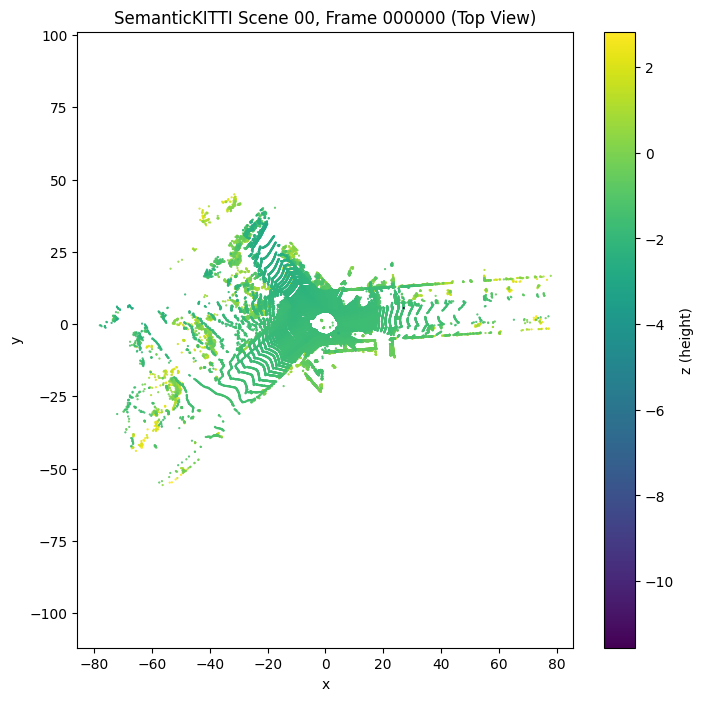

Loaded points: 124668
Intensity stats (min/mean/max): 0.0 0.29413402 0.99


In [4]:
import matplotlib.pyplot as plt

# Visualize one frame from a chosen scene with a top-down (x-y) view.
scene_id = "00"
frame_id = "000000"
sample_file = root_path / scene_id / "velodyne" / f"{frame_id}.bin"

sample_points = np.fromfile(sample_file, dtype=np.float32).reshape(-1, 4)

plt.figure(figsize=(8, 8))
plt.scatter(
    sample_points[:, 0],
    sample_points[:, 1],
    c=sample_points[:, 2],
    s=0.3,
    cmap="viridis",
)
plt.colorbar(label="z (height)")
plt.title(f"SemanticKITTI Scene {scene_id}, Frame {frame_id} (Top View)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

print("Loaded points:", sample_points.shape[0])
print("Intensity stats (min/mean/max):", sample_points[:, 3].min(), sample_points[:, 3].mean(), sample_points[:, 3].max())

In [5]:
from pathlib import Path

# SemanticKITTI labels live in a parallel labels folder, one .label per .bin frame.
labels_root = Path("/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/datasets/SemanticKITII/data_odometry_labels/dataset/sequences")
label_file = labels_root / scene_id / "labels" / f"{frame_id}.label"

raw_labels = np.fromfile(label_file, dtype=np.uint32)
semantic_labels = raw_labels & 0xFFFF
instance_ids = raw_labels >> 16

print("Label file:", label_file)
print("Raw label shape:", raw_labels.shape)
print("Semantic labels shape:", semantic_labels.shape)
print("Instance ids shape:", instance_ids.shape)
print("Point/label count match:", sample_points.shape[0] == semantic_labels.shape[0])

unique_sem, counts_sem = np.unique(semantic_labels, return_counts=True)
print("Unique semantic classes in this frame:", len(unique_sem))
print("Top 10 semantic IDs by count:")
order = np.argsort(counts_sem)[::-1][:10]
for i in order:
    print(f"class {int(unique_sem[i]):>3}: {int(counts_sem[i])}")

Label file: /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/datasets/SemanticKITII/data_odometry_labels/dataset/sequences/00/labels/000000.label
Raw label shape: (124668,)
Semantic labels shape: (124668,)
Instance ids shape: (124668,)
Point/label count match: True
Unique semantic classes in this frame: 17
Top 10 semantic IDs by count:
class  40: 34228
class  70: 27123
class  48: 26360
class  50: 18268
class  10: 4234
class  44: 3268
class  72: 2964
class   0: 2184
class  52: 1471
class  99: 1227


In [7]:
import numpy as np
from pathlib import Path
import yaml

config_file = Path("/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/semantic-kitti-api/config/semantic-kitti.yaml")
if "cfg" not in globals() or not isinstance(globals().get("cfg"), dict):
    with open(config_file, "r") as f:
        cfg = yaml.safe_load(f)

learning_map = {int(k): int(v) for k, v in cfg["learning_map"].items()}
learning_map_inv = {int(k): int(v) for k, v in cfg["learning_map_inv"].items()}
label_names = {int(k): v for k, v in cfg["labels"].items()}

if "semantic_labels" in globals():
    semantic_only = semantic_labels
elif "labels" in globals():
    semantic_only = labels & 0xFFFF
else:
    labels_root = Path("/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/datasets/SemanticKITII/data_odometry_labels/dataset/sequences")
    label_file = labels_root / scene_id / "labels" / f"{frame_id}.label"
    semantic_only = np.fromfile(label_file, dtype=np.uint32) & 0xFFFF

train_labels = np.array([learning_map.get(int(lbl), 0) for lbl in semantic_only], dtype=np.uint8)
ontology_translation = learning_map

unique_train, counts_train = np.unique(train_labels, return_counts=True)
print("Ontology translation set to learning_map (original -> training classes).")
for train_id, count in zip(unique_train, counts_train):
    orig_id = learning_map_inv.get(int(train_id), int(train_id))
    class_name = label_names.get(int(orig_id), f"class_{int(train_id)}")
    print(f"train_id={int(train_id):>3}  orig_id={int(orig_id):>3}  name={class_name:20}  count={int(count)}")

print("Training label array shape:", train_labels.shape)
print("First 20 training labels:", train_labels[:20])

Ontology translation set to learning_map (original -> training classes).
train_id=  0  orig_id=  0  name=unlabeled             count=4886
train_id=  1  orig_id= 10  name=car                   count=4234
train_id=  8  orig_id= 32  name=motorcyclist          count=88
train_id=  9  orig_id= 40  name=road                  count=35281
train_id= 10  orig_id= 44  name=parking               count=3268
train_id= 11  orig_id= 48  name=sidewalk              count=26360
train_id= 13  orig_id= 50  name=building              count=18268
train_id= 14  orig_id= 51  name=fence                 count=370
train_id= 15  orig_id= 70  name=vegetation            count=27123
train_id= 16  orig_id= 71  name=trunk                 count=1192
train_id= 17  orig_id= 72  name=terrain               count=2964
train_id= 18  orig_id= 80  name=pole                  count=532
train_id= 19  orig_id= 81  name=traffic-sign          count=102
Training label array shape: (124668,)
First 20 training labels: [0 0 0 0 0 0 0 0 0 

In [8]:
import numpy as np
from pathlib import Path

# Determine label file path (reuse variables if present)
try:
    lf = label_file
except NameError:
    lf = root_path / scene_id / "labels" / f"{frame_id}.label"

print("Reading label file:", lf)
raw = np.fromfile(lf, dtype=np.uint32)
uniq_raw, counts = np.unique(raw, return_counts=True)

print(f"Total points in label file: {raw.shape[0]}")
print('\nUnique packed (raw) labels and counts:')
for r, c in zip(uniq_raw, counts):
    sem = int(r & 0xFFFF)
    inst = int(r >> 16)
    print(f"raw={int(r):10}   sem={sem:4}   inst={inst:6}   count={int(c)}")

print('\nUnique semantic IDs in this frame:', np.unique(raw & 0xFFFF))
print('Example non-zero instance ids (first 20):', np.unique(raw >> 16)[np.unique(raw >> 16) != 0][:20])


Reading label file: /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/datasets/SemanticKITII/data_odometry_labels/dataset/sequences/00/labels/000000.label
Total points in label file: 124668

Unique packed (raw) labels and counts:
raw=         0   sem=   0   inst=     0   count=2184
raw=         1   sem=   1   inst=     0   count=4
raw=        40   sem=  40   inst=     0   count=34228
raw=        44   sem=  44   inst=     0   count=3268
raw=        48   sem=  48   inst=     0   count=26360
raw=        50   sem=  50   inst=     0   count=18268
raw=        51   sem=  51   inst=     0   count=370
raw=        52   sem=  52   inst=     0   count=1471
raw=        60   sem=  60   inst=     0   count=1053
raw=        70   sem=  70   inst=     0   count=27123
raw=        71   sem=  71   inst=     0   count=1192
raw=        72   sem=  72   inst=     0   count=2964
raw=        80   sem=  80   inst=     0   count=532
raw=        81   sem=  81   inst=     0   count=102
raw=        


Color legend:
train_id | raw_id | class_name           | RGB             | color_name
------------------------------------------------------------------------------------------
       0 |      0 | unlabeled            | (0, 0, 0)       | black
       1 |     10 | car                  | (100, 150, 245) | gray
       8 |     32 | motorcyclist         | (150, 30, 90)   | brown
       9 |     40 | road                 | (255, 0, 255)   | magenta
      10 |     44 | parking              | (255, 150, 255) | pink
      11 |     48 | sidewalk             | (75, 0, 75)     | purple
      13 |     50 | building             | (255, 200, 0)   | orange
      14 |     51 | fence                | (255, 120, 50)  | orange
      15 |     70 | vegetation           | (0, 175, 0)     | green
      16 |     71 | trunk                | (135, 60, 0)    | brown
      17 |     72 | terrain              | (150, 240, 80)  | gray
      18 |     80 | pole                 | (255, 240, 150) | pink
      19 |     81

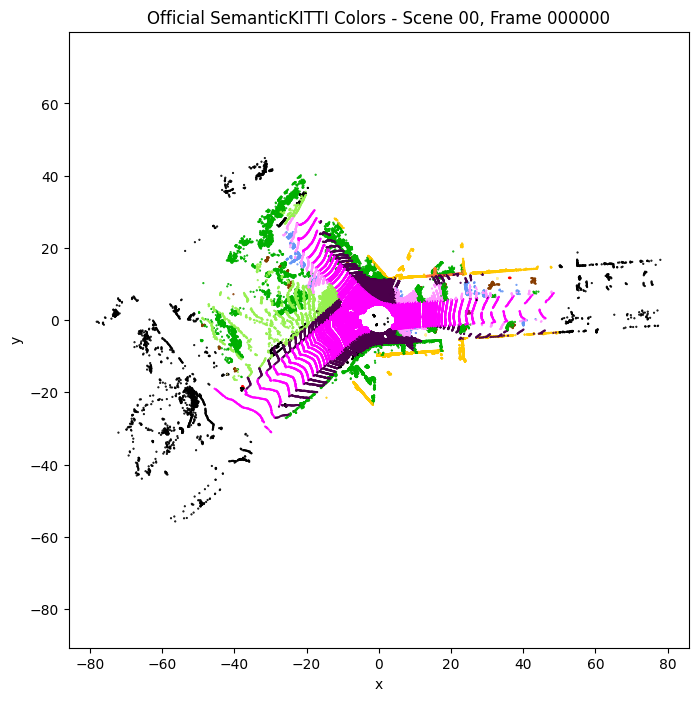

Visualized 124668 points colored by official SemanticKITTI class color


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

def closest_color_name(rgb_255):
    common_colors = {
        "black": (0, 0, 0),
        "white": (255, 255, 255),
        "red": (255, 0, 0),
        "green": (0, 128, 0),
        "blue": (0, 0, 255),
        "yellow": (255, 255, 0),
        "cyan": (0, 255, 255),
        "magenta": (255, 0, 255),
        "orange": (255, 165, 0),
        "purple": (128, 0, 128),
        "pink": (255, 192, 203),
        "brown": (165, 42, 42),
        "gray": (128, 128, 128),
        "lime": (0, 255, 0),
        "navy": (0, 0, 128),
        "teal": (0, 128, 128),
        "olive": (128, 128, 0),
        "maroon": (128, 0, 0),
    }

    rgb = np.array(rgb_255)
    closest_name = min(
        common_colors,
        key=lambda name: np.linalg.norm(rgb - np.array(common_colors[name]))
    )
    return closest_name


# Use the available point coordinates from earlier cells.
if "xyz" in globals():
    sample_points = xyz
elif "points" in globals():
    sample_points = points[:, :3]
else:
    raise NameError("No point coordinates found. Run the point-loading cell first.")

# Use sensible defaults if the scene/frame identifiers are not already defined.
scene_id = globals().get("scene_id", "00")
frame_id = globals().get("frame_id", "000000")

# Paths
labels_root = Path(
    "/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/"
    "datasets/SemanticKITII/data_odometry_labels/dataset/sequences"
)

scan_root = Path(
    "/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/"
    "datasets/SemanticKITII/data_odometry_velodyne/dataset/sequences"
)

config_file = Path(
    "/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/"
    "semantic-kitti-api/config/semantic-kitti.yaml"
)

label_file = labels_root / scene_id / "labels" / f"{frame_id}.label"
scan_file = scan_root / scene_id / "velodyne" / f"{frame_id}.bin"

# Load config
if "cfg" not in globals() or not isinstance(globals().get("cfg"), dict):
    with open(config_file, "r") as f:
        cfg = yaml.safe_load(f)

# Load labels
if "semantic_labels" in globals():
    semantic_labels_local = semantic_labels
elif "labels" in globals():
    semantic_labels_local = labels & 0xFFFF
else:
    raw_labels = np.fromfile(label_file, dtype=np.uint32)
    semantic_labels_local = raw_labels & 0xFFFF

# If coordinates and labels do not match, reload the scan for the same frame.
if sample_points.shape[0] != semantic_labels_local.shape[0]:
    sample_points = np.fromfile(scan_file, dtype=np.float32).reshape(-1, 4)[:, :3]

# Convert raw semantic labels to training labels
if "train_labels" in globals() and len(train_labels) == sample_points.shape[0]:
    train_labels_local = train_labels
else:
    learning_map = {int(k): int(v) for k, v in cfg["learning_map"].items()}
    train_labels_local = np.array(
        [learning_map.get(int(lbl), 0) for lbl in semantic_labels_local],
        dtype=np.uint8
    )

# Keep arrays aligned
count = min(sample_points.shape[0], train_labels_local.shape[0])
sample_points = sample_points[:count]
train_labels_local = train_labels_local[:count]

# SemanticKITTI mappings
color_map = {int(k): v for k, v in cfg["color_map"].items()}
learning_map_inv = {int(k): int(v) for k, v in cfg["learning_map_inv"].items()}
labels_dict = {int(k): str(v) for k, v in cfg["labels"].items()}

# Get unique training labels present in this frame
unique_train_labels = np.unique(train_labels_local)

# Build palette using official SemanticKITTI colors
palette = {}

for train_id in unique_train_labels:
    train_id = int(train_id)

    # Convert training ID back to raw SemanticKITTI ID
    raw_id = learning_map_inv.get(train_id, 0)

    # Get official color from SemanticKITTI config
    bgr = color_map.get(raw_id, [0, 0, 0])

    # SemanticKITTI color_map is BGR, matplotlib expects RGB
    rgb = np.array(bgr[::-1]) / 255.0

    palette[train_id] = rgb

# Assign color to every point
point_colors = np.array([palette[int(label)] for label in train_labels_local])

# Print legend
print("\nColor legend:")
print("train_id | raw_id | class_name           | RGB             | color_name")
print("-" * 90)

for train_id in sorted(unique_train_labels):
    train_id = int(train_id)

    raw_id = learning_map_inv.get(train_id, 0)
    class_name = labels_dict.get(raw_id, "unknown")

    rgb_float = palette[train_id]
    rgb_255 = tuple((rgb_float * 255).astype(int))
    color_name = closest_color_name(rgb_255)

    print(f"{train_id:8d} | {raw_id:6d} | {class_name:20s} | {str(rgb_255):15s} | {color_name}")

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(
    sample_points[:, 0],
    sample_points[:, 1],
    c=point_colors,
    s=0.3
)

plt.title(f"Official SemanticKITTI Colors - Scene {scene_id}, Frame {frame_id}")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

print("Visualized", sample_points.shape[0], "points colored by official SemanticKITTI class color")

In [9]:
import numpy as np
import open3d as o3d
from pathlib import Path
import matplotlib.pyplot as plt
import yaml

dataset_root = Path("/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/datasets/SemanticKITII/data_odometry_velodyne/dataset")
config_file = Path("/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/semantic-kitti-api/config/semantic-kitti.yaml")

seq = "00"
frame = "000300"

with open(config_file, "r") as f:
    cfg = yaml.safe_load(f)

bin_file = dataset_root / "sequences" / seq / "velodyne" / f"{frame}.bin"
label_file = dataset_root / "sequences" / seq / "labels" / f"{frame}.label"

points = np.fromfile(bin_file, dtype=np.float32).reshape(-1, 4)
labels = np.fromfile(label_file, dtype=np.uint32)
sem_labels = labels & 0xFFFF

xyz = points[:, :3]

color_map = cfg["color_map"]
max_label = max(color_map.keys()) 
lookup = np.zeros((max_label + 1, 3), dtype=np.float32)

for k, v in color_map.items():
    lookup[int(k)] = np.array(v[::-1]) / 255.0

default_color = np.array([0.5, 0.5, 0.5], dtype=np.float32)
colors = np.array([lookup[l] if l <= max_label else default_color for l in sem_labels])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)
pcd.colors = o3d.utility.Vector3dVector(colors)

o3d.visualization.draw_geometries([pcd])

In [11]:
import sys
from pathlib import Path

import numpy as np
import open3d as o3d
import yaml


def visualize_semantickitti_gt(
    dataset_root: str | Path,
    config_file: str | Path,
    sequence: str = "00",
    frame: str = "000000",
    show_instances: bool = False,
):
    """Load a SemanticKITTI scan and visualize the GT labels in Open3D.

    This version uses the repo's `SemLaserScan` helpers to load the scan,
    read the label file, and colorize the points.
    """
    dataset_root = Path(dataset_root)
    config_file = Path(config_file)
    repo_root = Path("/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/semantic-kitti-api")

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))

    from auxiliary.laserscan import SemLaserScan

    with open(config_file, "r") as f:
        cfg = yaml.safe_load(f)

    sem_color_dict = {int(k): v for k, v in cfg["color_map"].items()}
    scan = SemLaserScan(sem_color_dict, project=False)

    scan_file = dataset_root / "sequences" / sequence / "velodyne" / f"{frame}.bin"
    label_file = dataset_root / "sequences" / sequence / "labels" / f"{frame}.label"

    scan.open_scan(str(scan_file))
    scan.open_label(str(label_file))
    scan.colorize()

    xyz = scan.points
    semantic_labels = scan.sem_label
    instance_labels = scan.inst_label
    colors = scan.sem_label_color

    if show_instances:
        unique_instances = np.unique(instance_labels)
        print("Instance IDs in frame:", unique_instances[:20])

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    pcd.colors = o3d.utility.Vector3dVector(colors)

    o3d.visualization.draw_geometries([pcd])
    return pcd, semantic_labels, instance_labels


In [8]:
# Example call (do not run until the required visualization packages are installed)
pcd, semantic_labels, instance_labels = visualize_semantickitti_gt(
    dataset_root="/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/datasets/SemanticKITII/data_odometry_velodyne/dataset",
    config_file="/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/semantic-kitti-api/config/semantic-kitti.yaml",
    sequence="00",
    frame="000000",
    show_instances=False,
)


NameError: name 'visualize_semantickitti_gt' is not defined